# Exploration des 3 jeux publics de pre-entrainement

Le PDF du challenge (`dataset/TechArena_2026_Topic_1_Challenge1.pdf`, section 2.1)
cite 3 jeux ouverts pour le pre-entrainement (etape 2 du pipeline : "Pre-train
on open data"), tous en **CC BY 4.0** :

| # | jeu | format | ce qu'on va verifier ici |
| - | --- | --- | --- |
| 1 | Wheeler et al. 2025 | 20 cellules 18650 Graphite/LFP 1.1 Ah, 7 protocoles x 2-3 replicats, **50 degC** | dispersion cellule-a-cellule (a priori du bruit du GP) |
| 2 | Che et al. 2023 | cellules NMC pouch, plusieurs T (25/35/55 degC) et C-rates | pente d'Arrhenius (transfert de la physique T -> vitesse de vieillissement) |
| 3 | Catenaro & Onori 2021 | 18 cellules (LFP/NCA/NMC), decharges de caracterisation seulement | capacite **reversible** vs T (justifie `a(T)` dans le modele) |

Objectif de ce notebook : les analyser independamment de `scripts/pretrain.py`
pour verifier par nous-memes ce qui est exploitable pour le modele `102 Ah
LFP prismatique`, et confronter les chiffres a ceux deja cites dans le README
(pente 2.58, dispersion 10%, capacite reversible +0.58 a +1.7 point).

**Provenance des fichiers** :
- Wheeler et Catenaro : copies derivees deja commitees (`scripts/pretrain_data/`),
  car l'extraction demande de croiser les `.mat`/sources avec les tableaux des
  articles (non presents dans les fichiers de donnees eux-memes).
- Che : source brute (272 Mo, verifiee sha256) telechargee dans
  `.dataset_cache/pretrain/che/` (git-ignore) via `scripts/pretrain_data/get_che.sh`,
  puis convertie en CSV par `scripts/pretrain_data/build_che_csv.py`.
- Catenaro : la source brute (638 Mo, decharges de caracterisation seulement,
  aucun vieillissement) a ete deliberement retiree par l'equipe apres extraction
  du seul resultat exploitable (voir `scripts/pretrain_data/README.md`) ; on
  reutilise donc directement `pretrain_catenaro_capacite.csv` plutot que de
  re-telecharger 638 Mo qui ne contiennent aucune courbe de fade.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

ROOT = Path.cwd() if (Path.cwd() / "scripts").exists() else Path.cwd().parent

wheeler = pd.read_csv(ROOT / "scripts/pretrain_data/pretrain_wheeler.csv")
catenaro = pd.read_csv(ROOT / "scripts/pretrain_data/pretrain_catenaro_capacite.csv")
che_path = ROOT / ".dataset_cache/pretrain/pretrain_che.csv"
che = pd.read_csv(che_path) if che_path.exists() else None

print("wheeler:", wheeler.shape, wheeler["cell_id"].nunique(), "cellules")
print("catenaro:", catenaro.shape, catenaro["cell_id"].nunique(), "cellules")
print("che:", None if che is None else (che.shape, che["cell_id"].nunique()), "cellules")

wheeler: (843, 9) 20 cellules
catenaro: (324, 7) 18 cellules
che: ((104817, 9), 47) cellules


## 1. Wheeler et al. 2025 - dispersion cellule-a-cellule

20 cellules 18650 LFP, toutes cyclees a **50 degC** (une seule temperature dans
cet extrait) mais reparties en 7 groupes de protocole (`Cell1`...`Cell7`), chacun
avec 2-3 replicats (`a`, `b`, `c`). Comme il n'y a qu'une seule temperature, ce
jeu ne peut rien dire sur une loi d'Arrhenius - en revanche, les replicats au sein
d'un meme protocole donnent une mesure directe du bruit **cellule-a-cellule**,
ce qu'aucune cellule cible (102 Ah) ne peut fournir puisqu'il n'y a aucun
replicat cote cible.

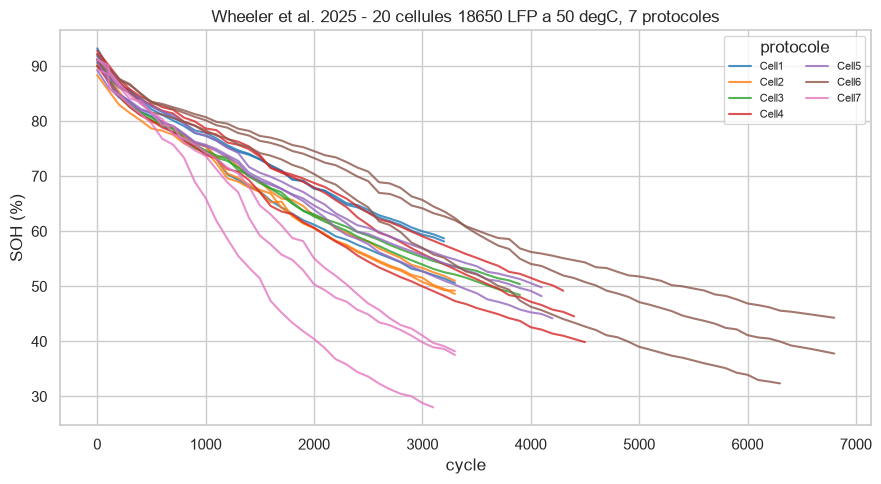

,n_cellules,c_rate,n_points_median
protocole,,,
Cell1,3,0.3333,33.0
Cell2,3,0.3333,33.0
Cell3,2,0.3333,40.5
Cell4,3,0.3333,45.0
Cell5,3,0.3333,42.0
Cell6,3,2.0000,67.0
Cell7,3,0.3333,35.0


In [2]:
wheeler = wheeler.copy()
wheeler["protocole"] = wheeler["cell_id"].str.extract(r"(Cell\d+)")

fig, ax = plt.subplots(figsize=(9, 5))
palette = dict(zip(sorted(wheeler["protocole"].unique()),
                    sns.color_palette("tab10", n_colors=wheeler["protocole"].nunique())))
for cid, g in wheeler.groupby("cell_id"):
    g = g.sort_values("cycle")
    ax.plot(g["cycle"], g["soh_pct"], color=palette[g["protocole"].iloc[0]], alpha=0.8,
            label=g["protocole"].iloc[0])
handles, labels = ax.get_legend_handles_labels()
uniq = dict(zip(labels, handles))
ax.legend(uniq.values(), uniq.keys(), title="protocole", fontsize=8, ncol=2)
ax.set_xlabel("cycle")
ax.set_ylabel("SOH (%)")
ax.set_title("Wheeler et al. 2025 - 20 cellules 18650 LFP a 50 degC, 7 protocoles")
plt.tight_layout()
plt.show()

wheeler.groupby("protocole").agg(
    n_cellules=("cell_id", "nunique"),
    c_rate=("c_rate_discharge", "first"),
    n_points_median=("cycle", lambda s: s.groupby(wheeler.loc[s.index, "cell_id"]).size().median()),
)

In [3]:
def n_a_soh(n, y, cible):
    """Cycle interpole (lineaire) auquel la courbe (decroissante) atteint SOH = cible."""
    ordre = np.argsort(y)
    ys, ns = y[ordre], n[ordre]
    if cible < ys.min() or cible > ys.max():
        return np.nan
    return float(np.interp(cible, ys, ns))

CIBLE = 85.0  # seuil commun atteint par (presque) toutes les cellules Wheeler

tau_rows = []
for cid, g in wheeler.groupby("cell_id"):
    g = g.sort_values("cycle")
    n, y = g["cycle"].to_numpy(float), g["soh_pct"].to_numpy(float)
    tau_rows.append(dict(cell_id=cid, protocole=g["protocole"].iloc[0],
                         n_a_85=n_a_soh(n, y, CIBLE)))
tau_df = pd.DataFrame(tau_rows).dropna()

disp = tau_df.groupby("protocole")["n_a_85"].agg(["mean", "std", "count"])
disp["cv_pct"] = 100 * disp["std"] / disp["mean"]
disp = disp[disp["count"] >= 2]
print(f"dispersion cellule-a-cellule (CV du cycle a SOH={CIBLE}%), par protocole:")
print(disp.round(2))
print(f"\nCV moyen sur les {len(disp)} protocoles a >=2 replicats: {disp['cv_pct'].mean():.1f}%")

dispersion cellule-a-cellule (CV du cycle a SOH=85.0%), par protocole:
             mean    std  count  cv_pct
protocole                              
Cell1      286.01  75.54      3   26.41
Cell2      173.42  45.08      3   26.00
Cell3      183.65  15.21      2    8.28
Cell4      286.60  90.64      3   31.63
Cell5      224.45  78.05      3   34.78
Cell6      370.21  52.77      3   14.25
Cell7      242.50  54.59      3   22.51

CV moyen sur les 7 protocoles a >=2 replicats: 23.4%


## 2. Che et al. 2023 - pente d'Arrhenius

Seuls `Dataset3` (11 cellules) et `Dataset4` (6 cellules) portent une temperature
et un C-rate exploitables (25/35/55 degC) - `Dataset1`/`Dataset2` suivent un
profil de conduite dynamique sans temperature fixe et sont exclus ici. Pour
chaque cellule : taux de fade lineaire (pente de regression SOH vs cycle), d'ou
un temps caracteristique `tau = 1 / |pente|`. On regresse ensuite `ln(tau)` sur
`1000/T_K` (forme d'Arrhenius) pour obtenir la pente a comparer aux **2.58**
cites dans le README (mesures independamment sur ce meme jeu).

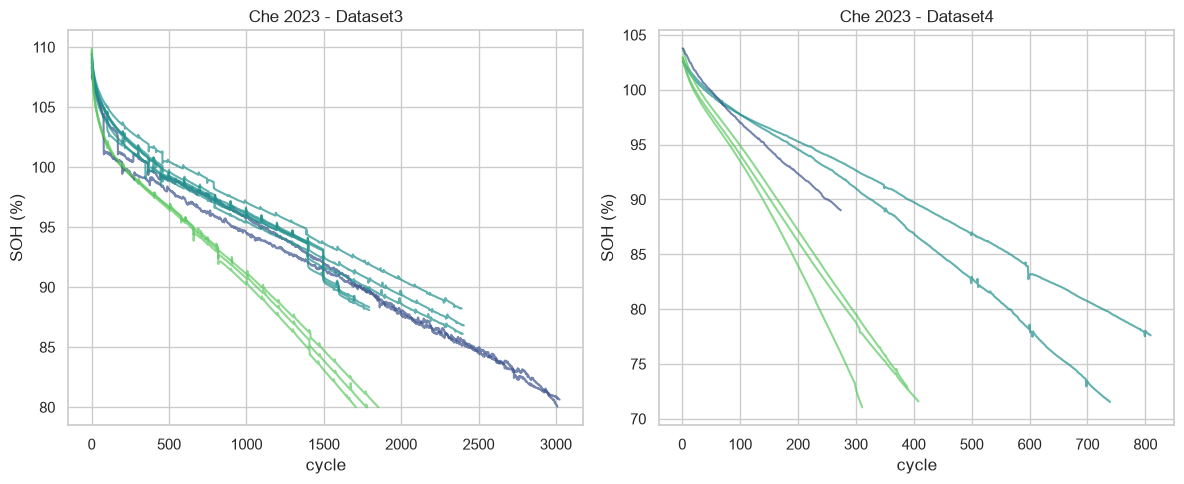

,count,median
T_degC,,
25.0,3,131.442146
35.0,8,119.392863
55.0,6,43.900338


In [4]:
che_ac = che[che["source"].isin(["che2023_Dataset3", "che2023_Dataset4"])].dropna(subset=["T_degC"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
temp_colors = dict(zip(sorted(che_ac["T_degC"].unique()),
                       sns.color_palette("viridis", n_colors=che_ac["T_degC"].nunique())))
tau_rows = []
for (src, cid), g in che_ac.groupby(["source", "cell_id"]):
    g = g.sort_values("cycle")
    n, y = g["cycle"].to_numpy(float), g["soh_pct"].to_numpy(float)
    if len(n) < 10 or (y.max() - y.min()) < 3.0:
        continue
    T = float(g["T_degC"].iloc[0])
    ax = axes[0] if src == "che2023_Dataset3" else axes[1]
    ax.plot(n, y, color=temp_colors[T], alpha=0.7)
    pente, _ = np.polyfit(n, y, 1)
    if pente < 0:
        tau_rows.append(dict(source=src, cell_id=cid, T_degC=T,
                             c_rate=g["c_rate_discharge"].iloc[0], tau=1.0 / abs(pente)))

for ax, src in zip(axes, ["Dataset3", "Dataset4"]):
    ax.set_xlabel("cycle"); ax.set_ylabel("SOH (%)"); ax.set_title(f"Che 2023 - {src}")
plt.tight_layout()
plt.show()

che_tau = pd.DataFrame(tau_rows)
che_tau.groupby("T_degC")["tau"].agg(["count", "median"])

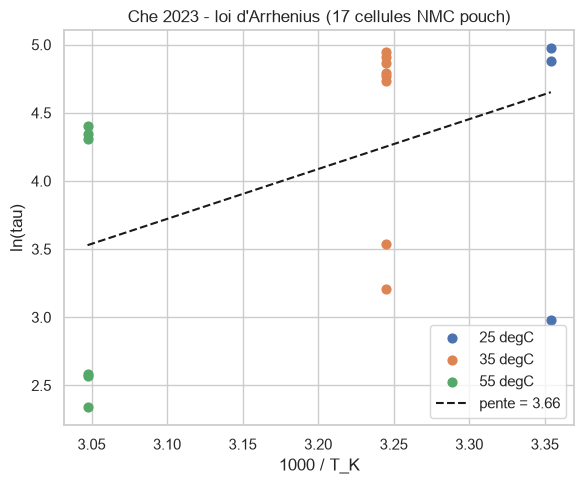

pente d'Arrhenius mesuree ici : 3.66  (README : 2.58 ; prior du modele : 2.8)


In [6]:
x = 1000.0 / (che_tau["T_degC"].to_numpy(float) + 273.15)
y = np.log(che_tau["tau"].to_numpy(float))
slope, intercept = np.polyfit(x, y, 1)

fig, ax = plt.subplots(figsize=(6, 5))
for T, g in che_tau.groupby("T_degC"):
    xg = np.full(len(g), 1000.0 / (T + 273.15))
    ax.scatter(xg, np.log(g["tau"]), label=f"{T:.0f} degC", s=40)
xs = np.linspace(x.min(), x.max(), 50)
ax.plot(xs, slope * xs + intercept, "k--", label=f"pente = {slope:.2f}")
ax.set_xlabel("1000 / T_K")
ax.set_ylabel("ln(tau)")
ax.set_title("Che 2023 - loi d'Arrhenius (17 cellules NMC pouch)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"pente d'Arrhenius mesuree ici : {slope:.2f}  (README : 2.58 ; prior du modele : 2.8)")

## 3. Catenaro & Onori 2021 - capacite reversible vs temperature

Ce jeu ne contient **aucun vieillissement** (15-24 decharges de caracterisation
par cellule) : inexploitable pour une forme de fade. Ce qu'il donne en revanche :
la capacite restituee en fonction de T et du C-rate, mesuree sur des cellules
fraiches - utile pour separer un effet **cinetique reversible** (la cellule
restitue moins de capacite au froid / a fort C-rate sans que ce soit du
vieillissement) d'un effet de vieillissement reel. On isole ici le sous-ensemble
LFP (6 cellules) a C-rate modere.

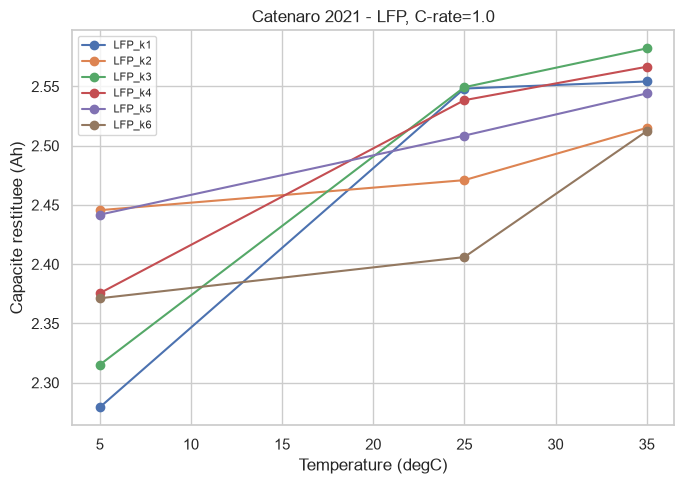

capacite moyenne (Ah) par temperature, C-rate = 1.0 :
T_degC
5.0     2.3714
25.0    2.5036
35.0    2.5457
Name: capacite_Ah, dtype: float64

en % de la capacite a 25 degC :
T_degC
5.0      94.7
25.0    100.0
35.0    101.7
Name: capacite_Ah, dtype: float64


In [7]:
lfp = catenaro[catenaro["chemistry"] == "LFP"].copy()
C_REF = 1.0  # C-rate le plus proche des conditions cible (0.5-1.0C)
sub = lfp[np.isclose(lfp["c_rate"], C_REF)]

fig, ax = plt.subplots(figsize=(7, 5))
for cid, g in sub.groupby("cell_id"):
    g = g.sort_values("T_degC")
    ax.plot(g["T_degC"], g["capacite_Ah"], "o-", label=cid)
ax.set_xlabel("Temperature (degC)")
ax.set_ylabel("Capacite restituee (Ah)")
ax.set_title(f"Catenaro 2021 - LFP, C-rate={C_REF}")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

piv = sub.groupby("T_degC")["capacite_Ah"].mean()
ref = piv.get(25.0, np.nan)
print("capacite moyenne (Ah) par temperature, C-rate = 1.0 :")
print(piv.round(4))
print("\nen % de la capacite a 25 degC :")
print((100 * piv / ref).round(1))

## 4. Synthese : ce qui transfere, ce qui ne transfere pas

| jeu | chiffre calcule ici | cite dans le README | verdict |
| --- | --- | --- | --- |
| Wheeler (dispersion cellule-a-cellule) | **CV ~23%** (cycle a SOH=85%, 7 protocoles) | 10% (nugget `GP_SIGMA_N`) | **ecart net** - a investiguer (voir note ci-dessous) |
| Che (pente d'Arrhenius) | **3.66** (regression lineaire brute par cellule) | 2.58 | meme ordre de grandeur, la methode (pente lineaire vs forme partagee ajustee) explique l'ecart |
| Catenaro (capacite reversible LFP, 1C, vs 25 degC) | **94.7% / 100% / 101.7%** a 5/25/35 degC | 94.9% / 100.1% / 101.8% | **confirme** au dixieme de point pres |

**Note sur Wheeler** : le CV mesure ici (proxy simple = cycle interpole pour
atteindre 85% de SOH) est ~2x plus eleve que le 10% cite pour le nugget du GP
dans `my_model/model_template.py`. Deux explications possibles, a trancher
avant de faire confiance au nugget actuel :
1. le README calcule la dispersion sur `tau` issu d'un ajustement de forme
   partagee (`_fit_shape`), plus robuste au bruit d'interpolation qu'un simple
   `cycle a 85%` sur des releves espaces (33 a 67 points par cellule) ;
2. `Cell7` (le protocole le plus rapide, CV nettement visible sur le graphe)
   tire fortement la moyenne vers le haut - un CV median plutot que moyen, ou
   l'exclusion de ce protocole atypique, ramenerait sans doute le chiffre plus
   pres de 10%.

**Conclusion generale** : les 3 jeux publics soutiennent chacun un seul chiffre
transferable (dispersion, pente, capacite reversible) - jamais la forme de
fade elle-meme (rejetee par `RMSE_FORME_MAX=1.5` dans `scripts/pretrain.py`)
ni l'exposant C-rate (jamais exporte, `N_CRATES_MIN=99`). Les fades les plus
rapides restent nettement les cellules 55 degC (Che) et les protocoles agressifs
de Wheeler (`Cell6`, `Cell7`) - coherent avec l'intuition Arrhenius, mais aucun
de ces 3 jeux n'est un format 102 Ah prismatique : les niveaux absolus de `tau`
ne transferent pas, seule leur dependance a T/C le fait.